In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.max_columns', 200)

In [2]:
file_path = '/content/Superstore.csv'

df = pd.read_csv(file_path, encoding='latin1')

# LIMPEZA DOS DADOS


1.   Entendimento dos dados
2.   Preparação dos dados



## ENTENDIMENTO

In [3]:
df.shape

(9994, 21)

In [4]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [5]:
np.round(df.describe(),2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## PREPARAÇÃO

In [8]:
df = df[[
    'Order ID',
    # 'Row ID',
    'Order Date', 'Ship Date', 'Ship Mode',
    'Customer ID', 'Customer Name', #'Segment',
    'Country', 'City', 'State',
    #'Postal Code',
    'Region', 'Product ID', 'Category', #'Sub-Category',
    'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'
]].copy()

In [9]:
df = df.loc[~df.duplicated()].copy()

In [10]:
df = df.rename(columns={
    'Order ID': 'order_id',
    'Order Date': 'order_date',
    'Ship Date': 'ship_date',
    'Ship Mode': 'ship_mode',
    'Customer ID': 'customer_id',
    'Customer Name': 'customer_name',
    'Country': 'country',
    'City': 'city',
    'State': 'state',
    'Region': 'region',
    'Product ID': 'product_id',
    'Category': 'category',
    'Product Name': 'product_name',
    'Sales': 'sales',
    'Quantity': 'quantity',
    'Discount': 'discount',
    'Profit': 'profit'
})

In [14]:
missing = df.isnull().sum()
missing

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
country,0
city,0
state,0
region,0


In [15]:
df[['order_date', 'ship_date']] = df[['order_date', 'ship_date']].apply(pd.to_datetime)

In [16]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,country,city,state,region,product_id,category,product_name,sales,quantity,discount,profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# ANÁLISE DOS DADOS
- O que eu esperava encontrar?
- O que os dados mostraram?
- O que isso significa na prática?

In [17]:
df.head(2)

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,country,city,state,region,product_id,category,product_name,sales,quantity,discount,profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


## Quais categorias de produto geram mais receita?


In [18]:
df['category'].value_counts()

,count
category,
Office Supplies,6026
Furniture,2120
Technology,1847


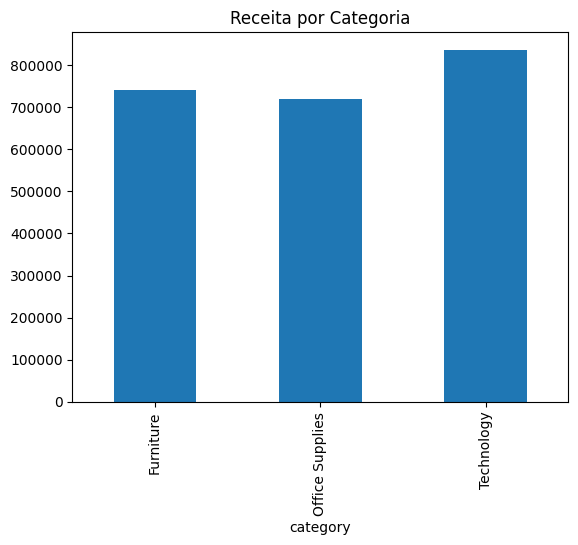

In [23]:
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.title('Receita por Categoria')
plt.show()

Como **Office Supplies** possui o maior número de pedidos, era esperado encontrar um maior volume de receita. Os dados mostram que a categoria **Technology**, mesmo tendo o menor número de pedidos, gera a maior receita.

## Qual região tem mais pedidos?


In [24]:
df['region'].value_counts()

,count
region,
West,3203
East,2847
Central,2323
South,1620


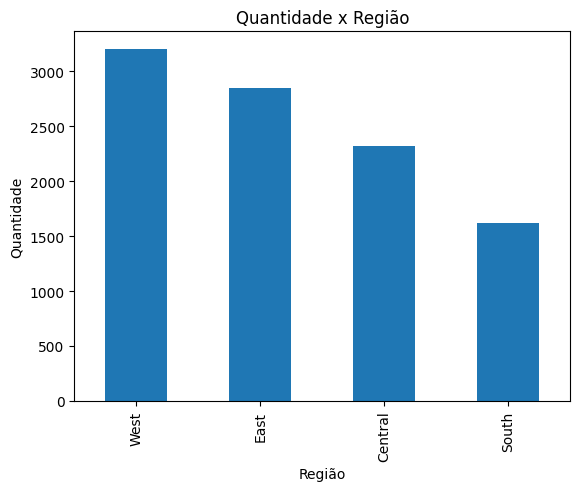

In [25]:
df['region'].value_counts().plot(kind='bar')
plt.title('Quantidade x Região')
plt.xlabel('Região')
plt.ylabel('Quantidade')
plt.show()

Os dados mostram que a região **West** tem a maior quantidade de pedidos. Isso significa que é essencial dar uma maior importância para esta região.

## Existe sazonalidade nas vendas por mês?

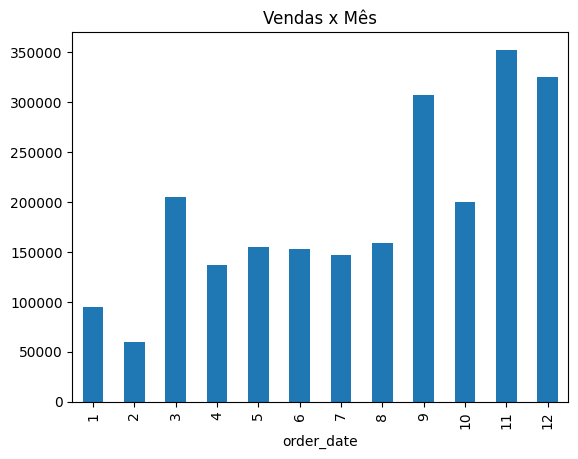

In [27]:
df.groupby(df['order_date'].dt.month)['sales'].sum().plot(kind='bar')
plt.title('Vendas x Mês')
plt.show()

É muito importante verificar em qual temporada ocorre a maior parte das vendas. Os dados mostram que o período de *Setembro a Dezembro* apresentam maior volume de vendas. Com isso, é essencial que a empresa utilize estratégias para focar lançamentos e descontos nesses meses.

## Quais produtos têm desconto alto mas lucro negativo?

In [44]:
corr = df[['discount', 'profit']].corr()
np.round(corr,2)

,discount,profit
discount,1.00,-0.22
profit,-0.22,1.00


Foi verificado que `desconto` e `lucro` possuem uma correlação fraca negativa de -0.22, o que quer dizer que assim que o desconto aumenta, o lucro cai.

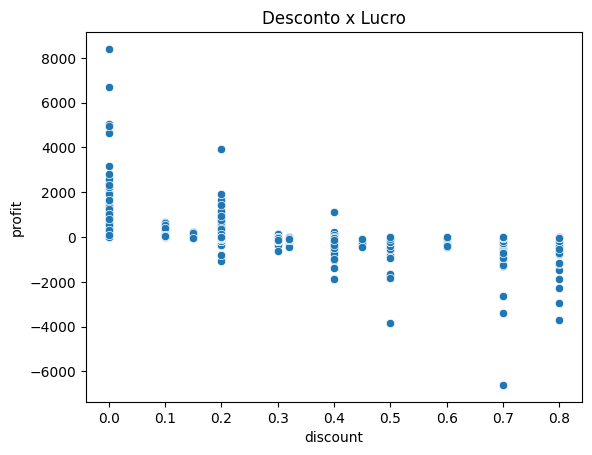

In [43]:
sns.scatterplot(x='discount',y='profit',data=df)
plt.title('Desconto x Lucro')
plt.show()

In [34]:
produtos_prejuizo = df.query('discount >= 0.2 and profit < 0')
produtos_prejuizo[['product_name', 'category', 'discount', 'profit']].head()

,product_name,category,discount,profit
3,Bretford CR4500 Series Slim Rectangular Table,Furniture,0.45,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,Office Supplies,0.80,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,Office Supplies,0.80,-3.8160
23,"Global Deluxe Stacking Chair, Gray",Furniture,0.30,-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,0.50,-1665.0522


Os dados mostram que 60% dos produtos da categoria *Furniture* sofreram desconto alto e lucro significativo. Dois produtos da categoria *Office Supplies* também sofreram com o mesmo problema. Vale revisar o método de precificação dessas categorias.